In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.9 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv
from itertools import combinations
import random
import networkx as nx
import matplotlib.pyplot as plt

Data(x=[3, 16], edge_index=[2, 4])
Induced subgraph:
Nodes: 3
Edge index shape: torch.Size([2, 4])


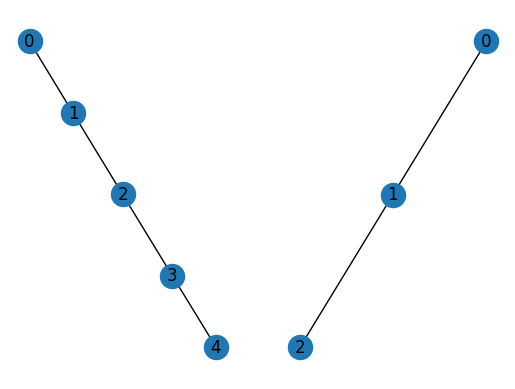

In [7]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import subgraph, k_hop_subgraph

import torch    # Create example graph
from torch_geometric.utils import subgraph
from torch_geometric.data import Data

def get_subgraph(data, node_idx):
    node_idx = torch.tensor(node_idx) if not isinstance(node_idx, torch.Tensor) else node_idx
    edge_index, _ = subgraph(node_idx, data.edge_index, relabel_nodes=True)
    x = data.x[node_idx] if data.x is not None else None
#    print(edge_index)
    return Data(x=x, edge_index=edge_index)

# Example usage
edge_index = torch.tensor([[0, 1, 1, 2, 2, 3, 3, 4],
                               [1, 0, 2, 1, 3, 2, 4, 3]], dtype=torch.long)
x = torch.randn(5, 16)  # 5 nodes, 16 features each
y = torch.tensor([0, 1, 0, 1, 0])
train_mask = torch.tensor([True, False, True, False, False])

data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask).to('cpu')

    # Example 1: Induced subgraph of nodes [0, 1, 2]
nodes=[0, 1, 2]
subgraph1 = get_subgraph(data, nodes)
g0=nx.Graph()
print(subgraph1)

g0.add_edges_from(data.edge_index.T.numpy())
plt.subplot(1,2,1)
nx.draw(g0,with_labels=True)
g1=nx.Graph()
g1.add_edges_from(subgraph1.edge_index.T.numpy())
plt.subplot(1,2,2)
nx.draw(g1,with_labels=True)

print("Induced subgraph:")
print(f"Nodes: {subgraph1.num_nodes}")
print(f"Edge index shape: {subgraph1.edge_index.shape}")

In [8]:
class OrderEmbedding(nn.Module):
    """Order embedding model for subgraph relationships"""
    def __init__(self, node_dim, hidden_dim, embed_dim):
        super().__init__()
        self.gnn = GCNConv(node_dim, hidden_dim)
        self.projection = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )
        self.embed_dim = embed_dim

    def forward(self, x, edge_index, batch):
        # GNN encoding
        h = F.relu(self.gnn(x, edge_index))
        # Global mean pooling
        graph_embed = torch.zeros(batch.max()+1, h.size(1), device=h.device)
        graph_embed = graph_embed.index_add_(0, batch, h)
        counts = torch.bincount(batch)
        graph_embed = graph_embed / counts.unsqueeze(1).float()
        # Projection to order embedding space
        return self.projection(graph_embed)


In [9]:
def generate_training_pairs(graphs, num_pairs=1000):
    """Generate (subgraph, supergraph) pairs and negative samples"""
    pairs = []
    labels = []
    for _ in range(num_pairs):
        # Positive pair
        try:
         g1 = random.sample(graphs, 1)[0]
         nodes = random.sample(range(g1.x.shape[0]), 4)
         g2 = get_subgraph(g1, nodes)
         pairs.append((g1, g2))
         labels.append(1)
        # Negative pair (non-subgraph relationship)
         g3, g4 = random.sample(graphs, 2)
#         if not (is_subgraph(g3, g4) or is_subgraph(g4, g3)):
         if True:
            pairs.append((g3, g4))
            labels.append(0)
        except:
          pass
        if len(labels)>num_pairs:
          break
    return pairs, labels

def order_loss(sub_embed, super_embed, margin=1.0):
    """Order embedding loss: ||[sub - super]+||^2"""
    diff = F.relu(sub_embed - super_embed)
    return torch.sum(diff ** 2, dim=1)

def contrastive_loss(embeddings, labels, margin=1.1):
    """Combined loss for positive/negative pairs"""
    sub_embed, super_embed = embeddings
    pos_loss = order_loss(sub_embed[labels==1], super_embed[labels==1])
    neg_loss = F.relu(margin - \
                      torch.norm(sub_embed[labels==0] - super_embed[labels==0], \
                                 dim=1)) ** 2
    return pos_loss.mean() + neg_loss.mean()


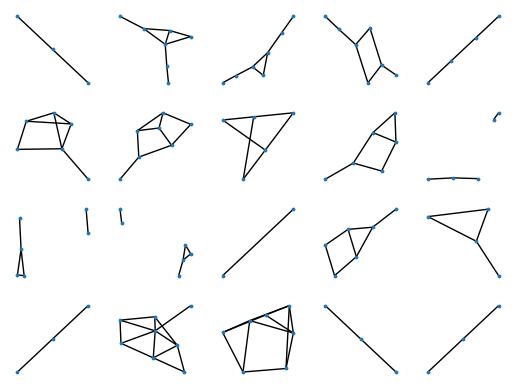

In [10]:
# Example usage
# Create synthetic graph dataset
graphs = []
for i in range(20):
        # Random graph
        num_nodes = random.randint(3, 8)
        x = torch.randn(num_nodes, 4)  # 4D node features
        edge_prob = 0.4
        edges = []
        for u, v in combinations(range(num_nodes), 2):
            if random.random() < edge_prob:
                edges.append([u, v])
                edges.append([v, u])  # Undirected
        edge_index = torch.tensor(edges).t() if edges else torch.empty(2, 0, dtype=torch.long)
        g0=nx.Graph()
        g0.add_edges_from(edges)
        plt.subplot(4,5,i+1)
        nx.draw(g0,node_size=3)
        graphs.append(Data(x=x, edge_index=edge_index))

In [11]:
pairs, labels = generate_training_pairs(graphs, num_pairs=500)
labels = torch.tensor(labels)
print(labels)
print(pairs[0][0])

tensor([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,

In [12]:
model = OrderEmbedding(node_dim=4, hidden_dim=16, embed_dim=8)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()
for epoch in range(100):
        total_loss = 0
        for i in range(0, len(pairs), 32):  # Batch processing
            batch_pairs = pairs[i:i+32]
            batch_labels = labels[i:i+32]

            sub_batch = Batch.from_data_list([p[0] for p in batch_pairs])
            sub_embed = model(sub_batch.x, sub_batch.edge_index, sub_batch.batch)

            super_batch = Batch.from_data_list([p[1] for p in batch_pairs])
            super_embed = model(super_batch.x, super_batch.edge_index, super_batch.batch)

            loss = contrastive_loss((sub_embed, super_embed), batch_labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss:.4f}")



Epoch 0, Loss: 8.3229
Epoch 20, Loss: 0.2344
Epoch 40, Loss: 0.0239
Epoch 60, Loss: 0.0023
Epoch 80, Loss: 0.0010


Data(x=[5, 4], edge_index=[2, 10]) Data(x=[7, 4], edge_index=[2, 22]) Data(x=[4, 4], edge_index=[2, 6])
x: tensor([[ 0.9300, -0.9473,  0.4226, -0.4567],
        [-0.5251, -0.9370, -0.8993,  0.0671],
        [ 0.3989, -0.4344, -0.4658,  0.4496],
        [-1.0549, -0.4310, -0.4899,  1.4630]]) e: tensor([[3, 1, 2, 0, 2, 1],
        [1, 3, 0, 2, 1, 2]]) xs: 4
subgraph: 0.0 not subgraph: 6.294604301452637


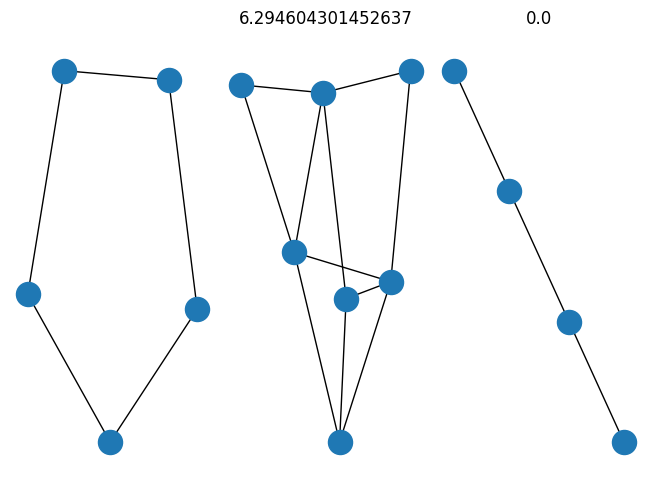

In [408]:
    # Test embedding properties
model.eval()
with torch.no_grad():
        # Embed two graphs
        g1, g2 = random.sample(graphs, 2)
        nodes=list(set(g1.edge_index[0].numpy()))
        k= 4 if 4<len(nodes) else len(nodes)-1
        get_nodes=[int(x) for x in random.sample(nodes,k)]
        g3 = get_subgraph(g1,get_nodes)
        print(g1,g2,g3)
        embed1 = model(g1.x, g1.edge_index, torch.zeros(g1.x.size(0), dtype=torch.long))
        embed2 = model(g2.x, g2.edge_index, torch.zeros(g2.x.size(0), dtype=torch.long))
        print('x:',g3.x,'e:',g3.edge_index,'xs:',g3.x.size(0))
        embed3 = model(g3.x, g3.edge_index, torch.zeros(g3.x.size(0), dtype=torch.long))
        eps12 = torch.sum(F.relu(embed1 - embed2)).item()
        eps13 = torch.sum(F.relu(embed1 - embed3)).item()
        print('subgraph:',eps13,'not subgraph:',eps12)
        plt.figure(constrained_layout=True)
        plt.subplot(1,3,1)
        g1d=nx.Graph()
        g1d.add_edges_from(g1.edge_index.T.numpy())
        nx.draw(g1d)
        plt.subplot(1,3,2)
        g2d=nx.Graph()
        plt.title(str(eps12))
        g2d.add_edges_from(g2.edge_index.T.numpy())
        nx.draw(g2d)
        plt.subplot(1,3,3)
        g3d=nx.Graph()
        plt.title(str(eps13))
        g3d.add_edges_from(g3.edge_index.T.numpy())
        nx.draw(g3d)

In [238]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import subgraph, k_hop_subgraph

def get_subgraph(data, node_idx, num_hops=None, relabel_nodes=True,
                keep_edges=True, return_edge_mask=False):
    """
    Extract a subgraph from a PyTorch Geometric Data object.

    Args:
        data (torch_geometric.data.Data): Input graph data object
        node_idx (int, list, or torch.Tensor): Node indices to extract subgraph for
        num_hops (int, optional): Number of hops for neighborhood extraction.
                                 If None, extracts induced subgraph of given nodes.
        relabel_nodes (bool): Whether to relabel node indices to be consecutive (0, 1, 2, ...)
        keep_edges (bool): Whether to keep only edges between selected nodes (for induced subgraph)
        return_edge_mask (bool): Whether to return edge mask indicating which edges were kept

    Returns:
        torch_geometric.data.Data: Subgraph data object
        (optional) torch.Tensor: Edge mask if return_edge_mask=True
    """

    node_idx = torch.tensor(node_idx)
    node_idx = node_idx.to(data.edge_index.device)

    if num_hops is not None:
        # Extract k-hop neighborhood
        subset, edge_index, mapping, edge_mask = k_hop_subgraph(
            node_idx=node_idx,
            num_hops=num_hops,
            edge_index=data.edge_index,
            relabel_nodes=relabel_nodes,
            num_nodes=data.num_nodes if hasattr(data, 'num_nodes') else len(set(list(node_idx)))
        )
    else:
        # Extract induced subgraph
        if keep_edges:
            edge_index, edge_attr, edge_mask = subgraph(
                subset=node_idx,
                edge_index=data.edge_index,
                relabel_nodes=relabel_nodes,
                return_edge_mask=True
            )
            subset = node_idx
        else:
            # Just return the specified nodes with no edges
            edge_index = torch.empty(2, 0, dtype=torch.long, device=data.edge_index.device)
            edge_mask = torch.empty(0, dtype=torch.bool, device=data.edge_index.device)
            subset = node_idx

    # Create new data object
    subgraph_data = Data()

    # Copy node features if they exist
    if hasattr(data, 'x') and data.x is not None:
        if relabel_nodes:
            subgraph_data.x = data.x[subset]
        else:
            # Create feature matrix with zeros for non-selected nodes
            # but typically we only want features for selected nodes
            subgraph_data.x = data.x[subset]

    # Copy edge features if they exist
    if hasattr(data, 'edge_attr') and data.edge_attr is not None:
        if num_hops is not None:
            # For k-hop, we already have the edge_mask from k_hop_subgraph
            if 'edge_mask' in locals():
                subgraph_data.edge_attr = data.edge_attr[edge_mask]
        else:
            subgraph_data.edge_attr = data.edge_attr[edge_mask]

    # Copy other attributes that should be subsetted
    for key in ['y', 'train_mask', 'val_mask', 'test_mask']:
        if hasattr(data, key) and getattr(data, key) is not None:
            attr = getattr(data, key)
            if attr.size(0) == data.num_nodes:
                if relabel_nodes:
                    setattr(subgraph_data, key, attr[subset])
                else:
                    # Create mask for all nodes but only set selected ones
                    new_attr = torch.zeros_like(attr)
                    new_attr[subset] = attr[subset]
                    setattr(subgraph_data, key, new_attr)

    # Set edge index and basic properties
    subgraph_data.edge_index = edge_index
    subgraph_data.num_nodes = subset.size(0) if relabel_nodes else data.num_nodes

    # Copy global attributes that don't need subsetting
    for key in ['edge_index', 'x', 'edge_attr', 'y', 'train_mask', 'val_mask', 'test_mask']:
        continue  # Already handled above

    # Copy any other attributes that are not node/edge specific
    for key in data.keys():
        if key not in ['x', 'edge_index', 'edge_attr', 'y', 'train_mask', 'val_mask', 'test_mask', 'num_nodes']:
            setattr(subgraph_data, key, getattr(data, key))

    if return_edge_mask:
        return subgraph_data, edge_mask
    else:
        return subgraph_data


# Convenience functions for common use cases
def get_induced_subgraph(data, node_idx, relabel_nodes=True):
    """
    Get induced subgraph containing only specified nodes and edges between them.

    Args:
        data: PyTorch Geometric Data object
        node_idx: Node indices to include in subgraph
        relabel_nodes: Whether to relabel nodes to consecutive indices

    Returns:
        Data: Induced subgraph
    """
    return get_subgraph(data, node_idx, num_hops=None, relabel_nodes=relabel_nodes)


def get_k_hop_subgraph(data, center_nodes, num_hops, relabel_nodes=True):
    """
    Get k-hop neighborhood subgraph around center nodes.

    Args:
        data: PyTorch Geometric Data object
        center_nodes: Center node indices
        num_hops: Number of hops to expand
        relabel_nodes: Whether to relabel nodes to consecutive indices

    Returns:
        Data: k-hop subgraph
    """
    return get_subgraph(data, center_nodes, num_hops=num_hops, relabel_nodes=relabel_nodes)


if True:
    # Create example graph
    edge_index = torch.tensor([[0, 1, 1, 2, 2, 3, 3, 4],
                               [1, 0, 2, 1, 3, 2, 4, 3]], dtype=torch.long)
    x = torch.randn(5, 16)  # 5 nodes, 16 features each
    y = torch.tensor([0, 1, 0, 1, 0])
    train_mask = torch.tensor([True, False, True, False, False])

    data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask)

    # Example 1: Induced subgraph of nodes [0, 1, 2]
    subgraph1 = get_induced_subgraph(data, [0, 1, 2])
    print("Induced subgraph:")
    print(f"Nodes: {subgraph1.num_nodes}")
    print(f"Edge index shape: {subgraph1.edge_index.shape}")
    print(f"Node features shape: {subgraph1.x.shape}")

    # Example 2: 2-hop neighborhood around node 2
    subgraph2 = get_k_hop_subgraph(data, [2], num_hops=2)
    print("\n2-hop neighborhood around node 2:")
    print(f"Nodes: {subgraph2.num_nodes}")
    print(f"Original node indices in subgraph: {subgraph2.original_nodes if hasattr(subgraph2, 'original_nodes') else 'Not stored'}")

    # Example 3: Get subgraph with edge mask
    subgraph3, edge_mask = get_subgraph(data, [1, 2, 3], return_edge_mask=True)
    print(f"\nEdge mask: {edge_mask}")
    print(f"Original edges kept: {edge_mask.sum().item()}/{data.edge_index.size(1)}")

Induced subgraph:
Nodes: 3
Edge index shape: torch.Size([2, 4])
Node features shape: torch.Size([3, 16])

2-hop neighborhood around node 2:
Nodes: 5
Original node indices in subgraph: Not stored

Edge mask: tensor([False, False,  True,  True,  True,  True, False, False])
Original edges kept: 4/8
